In [4]:
import sqlite3
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
import kagglehub
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("parsakh/global-e-commerce-and-supply-chain-database")

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import sqlite3

conn = sqlite3.connect("ecommerce_supply_chain.db")
cursor = conn.cursor()

In [7]:
data_dir = "/home/codespace/.cache/kagglehub/datasets/parsakh/global-e-commerce-and-supply-chain-database/versions/1"##Paste wherever path appears in the output of the previous cell

tables = {
    "customers": "customers.csv",
    "products": "products.csv",
    "suppliers": "supplier_costs.csv",
    "transactions": "transactions.csv",
    "inventory": "inventory.csv",
}

for table_name, filename in tables.items():
    df = pd.read_csv(os.path.join(data_dir, filename))
    df.to_sql(table_name, conn, if_exists="append", index=False)
    print(f"Loaded {table_name}: {df.shape[0]} rows")

Loaded customers: 8000 rows
Loaded products: 500 rows
Loaded suppliers: 998 rows
Loaded transactions: 100000 rows
Loaded inventory: 500 rows


In [8]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT *
FROM transactions t
"""
transactions_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [9]:
transactions_df.head()

,transaction_id,customer_id,product_id,date,quantity,unit_price_usd,discount_pct,revenue_usd,cost_usd,profit_usd,shipping_cost_usd,channel,payment_method,status,country,category
0,TXN000001,CUST05879,PROD0230,2023-05-15,1,21.66,0.0,21.66,13.00,8.66,7.24,organic_search,paypal,completed,UK,Home & Kitchen
1,TXN000002,CUST00461,PROD0055,2022-08-21,1,188.93,0.0,188.93,85.02,103.91,13.66,social_media,credit_card,completed,USA,Clothing
2,TXN000003,CUST03473,PROD0353,2023-08-28,5,202.21,0.0,1011.05,606.65,404.40,108.68,direct,paypal,completed,France,Home & Kitchen
3,TXN000004,CUST07458,PROD0253,2024-05-31,4,249.76,0.2,799.23,549.48,249.75,0.00,email,bank_transfer,completed,UK,Sports & Outdoors
4,TXN000005,CUST06099,PROD0206,2023-04-22,2,287.63,0.0,575.26,258.86,316.40,9.30,organic_search,credit_card,completed,USA,Clothing


In [10]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT *
FROM customers c
"""
customers_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [11]:
customers_df.head()

,customer_id,first_name,last_name,country,currency,age,gender,registration_date,is_premium,email_verified,email
0,CUST00001,Laura,Brown,UK,GBP,21,F,2020-10-12,0,1,laura.brown0001@email.com
1,CUST00002,Claire,Brown,Australia,AUD,47,M,2020-07-13,1,1,claire.brown0002@email.com
2,CUST00003,Thomas,Allen,Canada,CAD,68,M,2020-06-04,0,1,thomas.allen0003@email.com
3,CUST00004,William,Jackson,France,EUR,59,M,2020-12-12,0,0,william.jackson0004@email.com
4,CUST00005,Nina,Mueller,USA,USD,56,F,2021-10-24,0,1,nina.mueller0005@email.com


TOP Buying Costumers by Total Purchase Amount

In [12]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT  
  case
   when c.age <18 then 'Minor'
   when c.age between 18 and 35 then 'Young Adult'
   when c.age between 36 and 55 then 'Adult'
   when c.age > 55 then 'Elderly'
 END as age_range, 

 AVG(t.revenue_usd) AS average_purchase_amount 

 FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
JOIN products p ON t.product_id = p.product_id
GROUP BY age_range
ORDER BY average_purchase_amount DESC;"""

top_customers_by_age_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [13]:
top_customers_by_age_df.head()

,age_range,average_purchase_amount
0,Elderly,534.043215
1,Young Adult,531.991876
2,Adult,520.717992


In [14]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT  
  CASE
  when c.is_premium = 1 THEN 'Premium'
  ELSE 'Regular'
  END as customer_type,
 AVG(t.revenue_usd) AS average_purchase_amount,COUNT(DISTINCT c.customer_id) AS customer_count

 FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
JOIN products p ON t.product_id = p.product_id
GROUP BY customer_type
ORDER BY average_purchase_amount DESC;"""

premium_customers_df = pd.read_sql_query(sql_query, conn)

conn.close()

Text(0, 0.5, 'Customer Count')

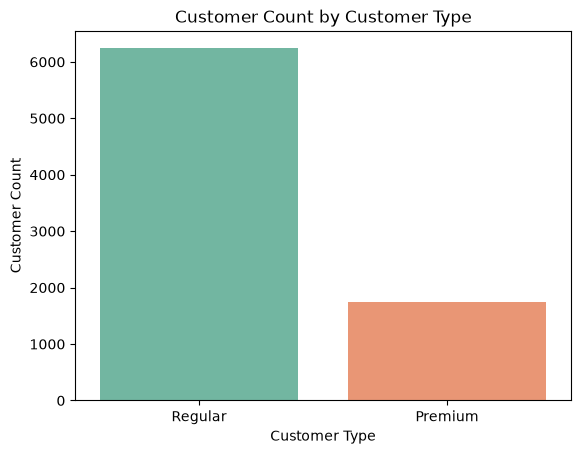

In [15]:
sns.barplot(data=premium_customers_df, x='customer_type', y='customer_count', hue='customer_type',palette='Set2',errorbar=None)
plt.title('Customer Count by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Customer Count')

In [16]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT  
  case
   when c.age <18 then 'Minor'
   when c.age between 18 and 35 then 'Young Adult'
   when c.age between 36 and 55 then 'Adult'
   when c.age > 55 then 'Elderly'
 END as age_range, 
  CASE
  when c.is_premium = 1 THEN 'Premium'
  ELSE 'Regular'
  END as customer_type,
 AVG(t.revenue_usd) AS average_purchase_amount,COUNT(DISTINCT c.customer_id) AS customer_count

 FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
JOIN products p ON t.product_id = p.product_id
GROUP BY age_range,customer_type
ORDER BY age_range,customer_count DESC;"""

premium_customers_df = pd.read_sql_query(sql_query, conn)

conn.close()

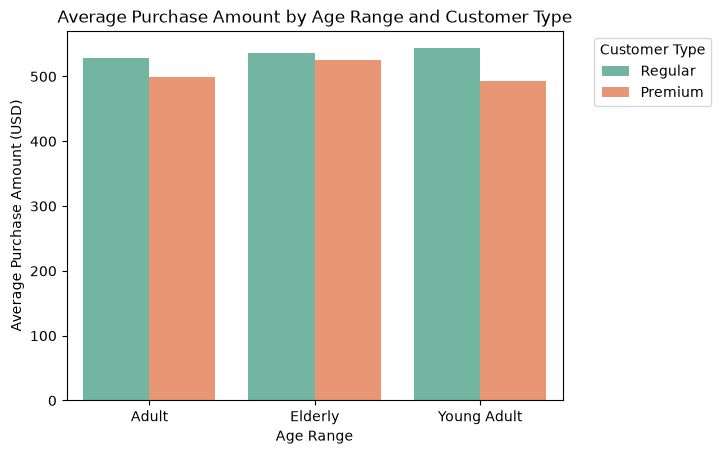

In [17]:
sns.barplot(data=premium_customers_df, x='age_range', y='average_purchase_amount', hue='customer_type',palette='Set2')
plt.title('Average Purchase Amount by Age Range and Customer Type')
plt.xlabel('Age Range')
plt.ylabel('Average Purchase Amount (USD)')
plt.legend(title='Customer Type', bbox_to_anchor=(1.05, 1), loc='upper left')

In [18]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT
    c.customer_id,
    julianday('2024-12-31') - julianday(MAX(t.date)) AS recency_days,
    COUNT(t.transaction_id) AS frequency,
    SUM(t.revenue_usd) AS monetary,c.is_premium,c.email,c.registration_date
FROM customers c
JOIN transactions t ON c.customer_id = t.customer_id
WHERE t.status = 'completed'
GROUP BY c.customer_id
ORDER BY frequency DESC
LIMIT 10;"""

rfm_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [19]:
rfm_df.head(10)

,customer_id,recency_days,frequency,monetary,is_premium,email,registration_date
0,CUST01713,0.0,15039,6861756.33,1,elena.mueller1713@email.com,2020-05-16
1,CUST01068,0.0,7884,4434332.22,0,sara.rossi1068@email.com,2020-09-16
2,CUST05248,3.0,7254,3854489.76,0,david.harris5248@email.com,2021-04-17
3,CUST03000,4.0,6714,3808164.69,0,james.jackson3000@email.com,2021-01-21
4,CUST00785,0.0,5436,3448227.42,0,sara.rossi0785@email.com,2021-02-16
5,CUST01593,0.0,3825,2071273.86,0,anna.dubois1593@email.com,2020-03-19
6,CUST04788,0.0,3429,1985147.64,0,robert.jackson4788@email.com,2020-02-09
7,CUST03425,0.0,2907,1633688.64,0,james.young3425@email.com,2021-11-18
8,CUST06388,3.0,2754,1508308.11,0,daniel.johnson6388@email.com,2020-06-20
9,CUST07467,0.0,2736,1376060.13,0,sara.harris7467@email.com,2021-09-15


Analysis of Shipping Cost and Profit per Country and Product

In [20]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT country, 
COUNT(DISTINCT customer_id) AS customer_count,
SUM(profit_usd) AS total_profit,
SUM(quantity) as Total_Units_Sold


FROM transactions t
WHERE status = 'completed'
GROUP BY country
ORDER BY customer_count DESC

LIMIT 10;"""

country_df = pd.read_sql_query(sql_query, conn)

conn.close()

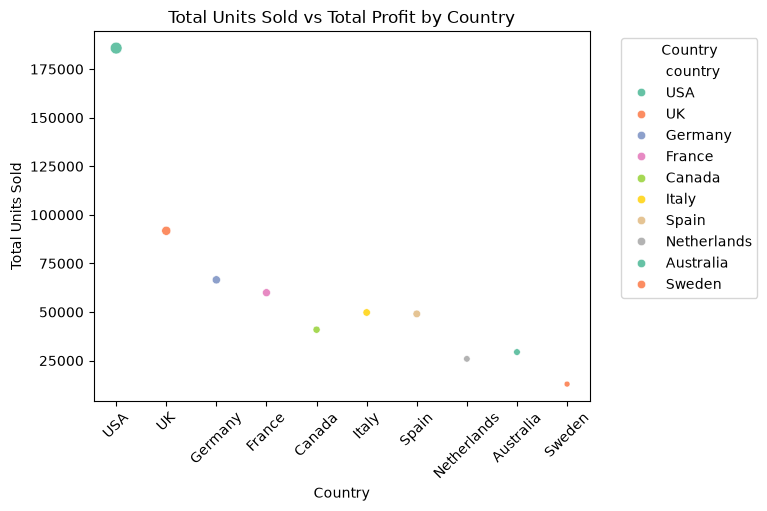

In [36]:
ax=sns.scatterplot(data=country_df, x='country', y='Total_Units_Sold', size='total_profit', hue='country', palette='Set2')
plt.title('Total Units Sold vs Total Profit by Country')
plt.xlabel('Country')
plt.ylabel('Total Units Sold')
handles, labels = ax.get_legend_handles_labels()
if "total_profit" in labels:
    cutoff = labels.index("total_profit")
    handles = handles[:cutoff]
    labels = labels[:cutoff]
    plt.legend(
    handles=handles,
    labels=labels,
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.xticks(rotation=45)
plt.show()

In [22]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT 
    strftime('%m', date) AS month,
    SUM(revenue_usd) AS total_revenue,
    SUM(profit_usd) AS total_profit,
    SUM(quantity) AS total_units_sold,
    COUNT(DISTINCT customer_id) AS customer_count

FROM transactions
WHERE status = 'completed'
GROUP BY month
ORDER BY month, total_revenue DESC
LIMIT 12;"""

best_months_df = pd.read_sql_query(sql_query, conn)

conn.close()

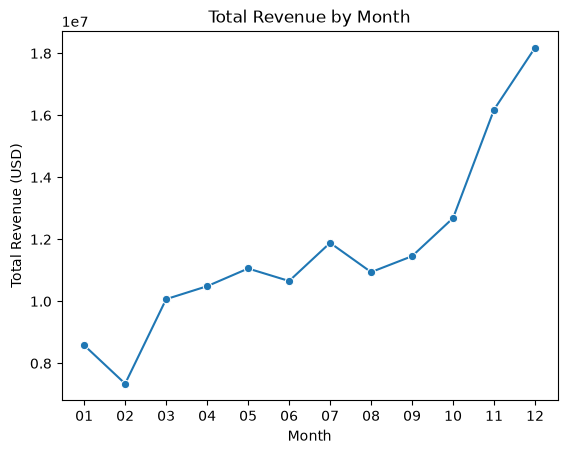

In [37]:
sns.lineplot(data=best_months_df, x='month', y='total_revenue', marker='o')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.show()

In [104]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """
SELECT 
    p.brand AS brand_name,
   ROUND(SUM(t.revenue_usd), 2) AS brand_revenue,
    SUM(t.quantity) AS brand_units,
    SUM(ROUND(SUM(t.revenue_usd), 2)) OVER () AS grand_total_revenue,
    ROUND(SUM(t.revenue_usd) * 100.0 / SUM(ROUND(SUM(t.revenue_usd), 2)) OVER (), 2) AS pct_of_total_revenue
FROM transactions t
JOIN products p ON t.product_id = p.product_id
WHERE t.status = 'completed'
GROUP BY p.brand
ORDER BY brand_revenue DESC;
"""

brand_share_df = pd.read_sql_query(sql_query, conn)

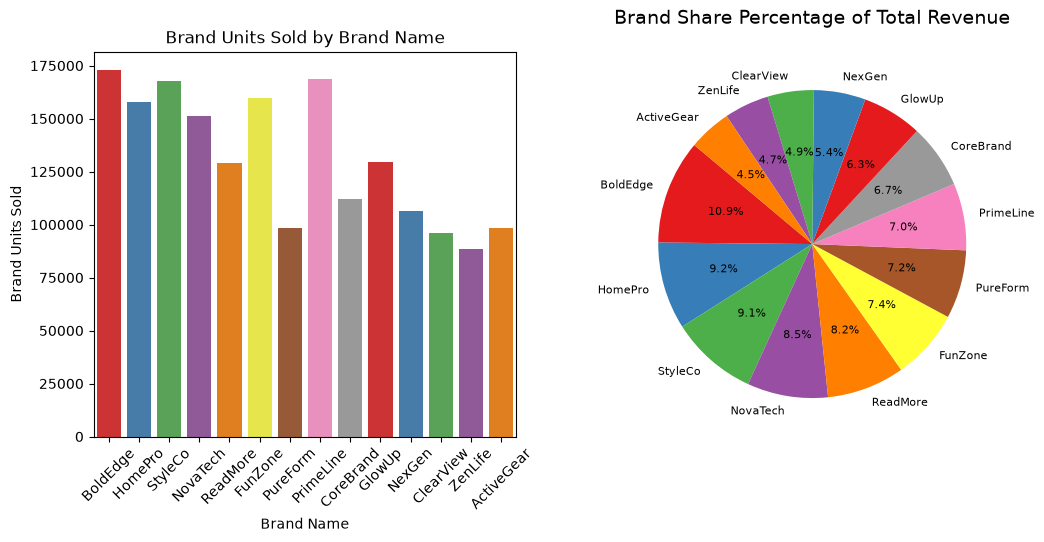

<Figure size 640x480 with 0 Axes>

In [109]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


ax2 = sns.barplot(
    data=brand_share_df,
    x="brand_name",
    y="brand_units",
    hue="brand_name",
    palette="Set1",
    ax=ax1,
    legend=False,
)
ax2.set_title("Brand Units Sold by Brand Name")
ax2.set_xlabel("Brand Name")
ax2.set_ylabel("Brand Units Sold")
ax2.tick_params(axis="x", rotation=45)


# 1. Choose a Seaborn color palette and extract the colors
colors = sns.color_palette("Set1", len(brand_share_df))

# 3. Create the pie chart using Matplotlib
ax2=plt.pie(
    x=brand_share_df["pct_of_total_revenue"],  # Numeric values for slices
    labels=brand_share_df["brand_name"],  # Text labels for slices
    colors=colors,  # Applies your Seaborn colors
    autopct="%1.1f%%",  # Displays percentage text format inside slices
    startangle=140,  # Rotates the starting position for better look
    textprops={"fontsize": 8},# Adjusts text size
      
)
palette = sns.color_palette("Set1", len(brand_share_df))
# 4. Add title and display
plt.title("Brand Share Percentage of Total Revenue", fontsize=14, pad=20)
plt.show()

plt.tight_layout()
plt.show()


In [110]:
sql_query = """
SELECT 
    p.brand AS brand_name,
    strftime('%m', t.date) AS month,
    ROUND(SUM(t.revenue_usd), 2) AS brand_revenue,
    SUM(t.quantity) AS brand_units
FROM transactions t
JOIN products p ON t.product_id = p.product_id
WHERE t.status = 'completed'
GROUP BY p.brand, month
ORDER BY month ASC, brand_revenue DESC;
"""

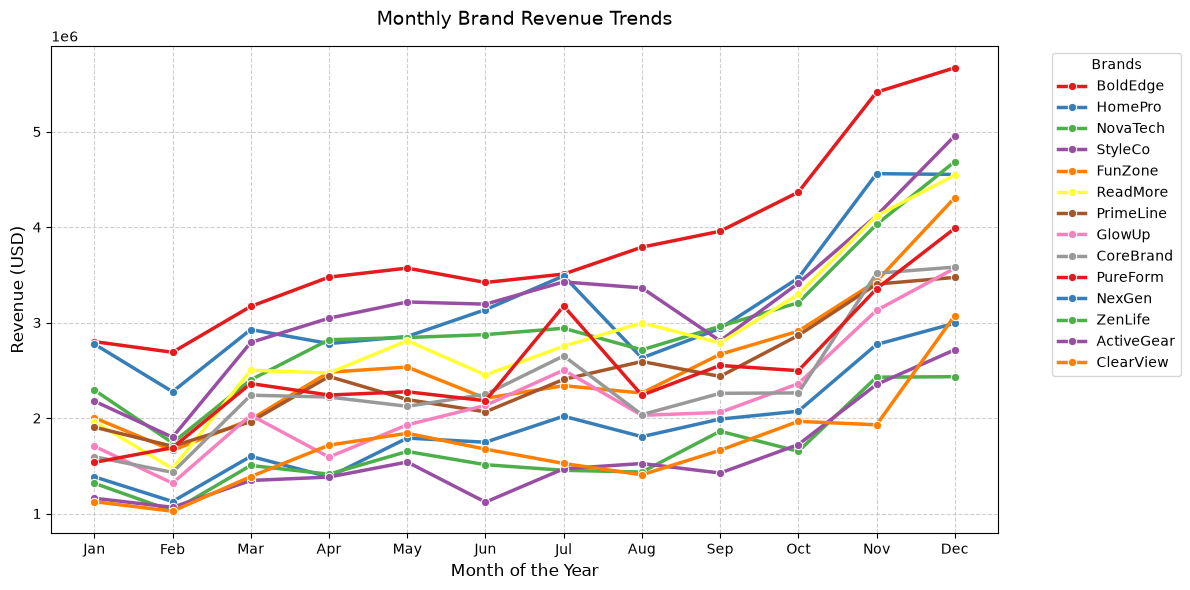

In [ ]:
# Load the structured time-series data
brand_monthly_df = pd.read_sql_query(sql_query, conn)

# 2. Build the line chart using Seaborn
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=brand_monthly_df,
    x="month",  # X-axis tracks the months
    y="brand_revenue",  # Y-axis tracks the sales revenue
    hue="brand_name",  # Creates a distinct colored line for each brand
    palette="Set1",  # Applies your high-contrast Set1 color scheme
    marker="o",  # Adds visible dot indicators on every month's data point
    linewidth=2.5,
)

# 3. Clean and polish the axis layout
plt.title("Monthly Brand Revenue Trends", fontsize=14, pad=15)
plt.xlabel("Month of the Year", fontsize=12)
plt.ylabel("Revenue (USD)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)  # Adds a clean background grid for tracking lines

plt.xticks(
    ticks=range(len(brand_monthly_df["month"].unique())),
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"][:len(brand_monthly_df["month"].unique())]
)
plt.legend(title="Brands", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()


In [26]:
sql_query = """
SELECT 
    CASE
        WHEN c.age < 18 THEN 'Minor'
        WHEN c.age BETWEEN 18 AND 35 THEN 'Young Adult'
        WHEN c.age BETWEEN 36 AND 55 THEN 'Adult'
        ELSE 'Elderly'
    END AS age_range,
    COUNT(DISTINCT c.customer_id) AS num_customers,
    SUM(t.revenue_usd) AS revenue,
    SUM(t.profit_usd) AS profit,
    SUM(t.quantity) AS units_sold
FROM transactions t
JOIN customers c ON t.customer_id = c.customer_id
JOIN products p ON t.product_id = p.product_id
WHERE p.brand = 'BoldEdge'
    
GROUP BY age_range
ORDER BY num_customers DESC;
"""

age_profile_df = pd.read_sql_query(sql_query, conn)

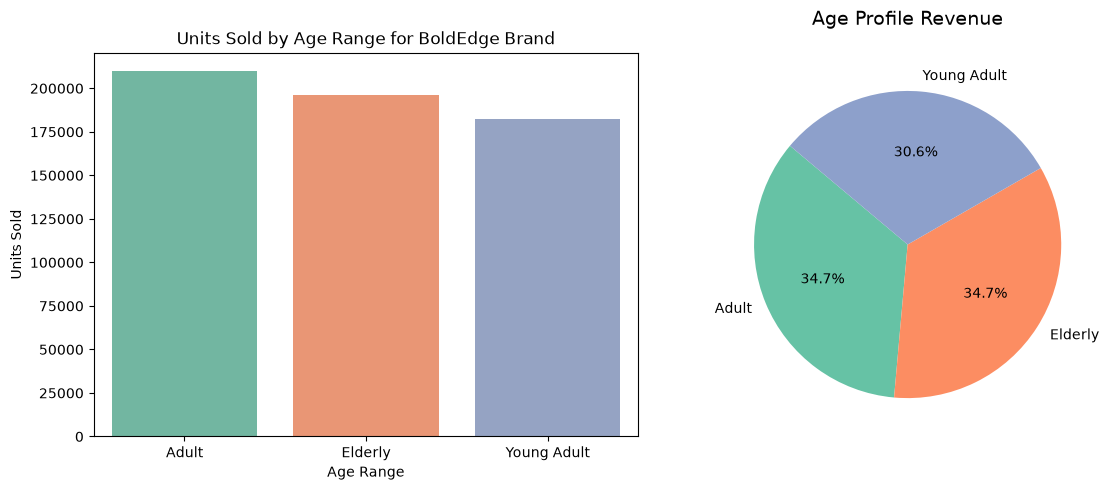

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1=sns.barplot(data=age_profile_df, x='age_range', y='units_sold', hue='age_range', palette='Set2', errorbar=None,ax=ax1)
ax1.set_title('Units Sold by Age Range for BoldEdge Brand')
ax1.set_xlabel('Age Range')
ax1.set_ylabel('Units Sold')
colors = sns.color_palette("Set2", len(brand_share_df))

# 2. Set up the figure canvas

# 3. Create the pie chart using Matplotlib
ax2=plt.pie(
    x=age_profile_df["revenue"],  # Numeric values for slices
    labels=age_profile_df["age_range"],  # Text labels for slices
    colors=colors,  # Applies your Seaborn colors
    autopct="%1.1f%%",  # Displays percentage text format inside slices
    startangle=140,  # Rotates the starting position for better look
    textprops={"fontsize": 10},# Adjusts text size
      
)

palette = sns.color_palette("Set1", len(brand_share_df))
# 4. Add title and display
plt.title("Age Profile Revenue", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [113]:
sql_query = """
SELECT
    t.country,
    p.brand,
    SUM(t.revenue_usd) AS brand_revenue,
    SUM(SUM(t.revenue_usd)) OVER (PARTITION BY t.country) AS country_total_revenue,
    ROUND(SUM(t.revenue_usd) * 100.0 / SUM(SUM(t.revenue_usd)) OVER (PARTITION BY t.country), 2) AS pct_of_country_revenue
FROM transactions t
JOIN products p ON t.product_id = p.product_id
WHERE t.status = 'completed'
GROUP BY t.country, p.brand
ORDER BY t.country, pct_of_country_revenue DESC;"""

country_brand_df = pd.read_sql_query(sql_query, conn)

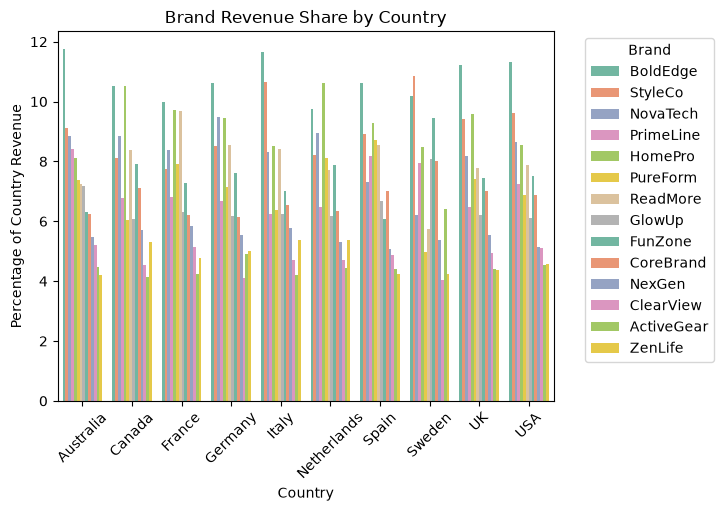

In [117]:
sns.barplot(data=country_brand_df, x='country', y='pct_of_country_revenue', hue='brand', palette='Set2')
plt.title('Brand Revenue Share by Country')
plt.xlabel('Country')
plt.ylabel('Percentage of Country Revenue')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()  

In [137]:
sql_query = """SELECT
    p.brand,
    i.stock_units AS stock_level,
    SUM(t.quantity) AS units_sold
FROM products p
JOIN inventory i ON p.product_id = i.product_id
JOIN transactions t ON p.product_id = t.product_id
WHERE p.brand = 'BoldEdge' AND t.status = 'completed'
GROUP BY p.brand, i.stock_units
ORDER BY units_sold DESC;"""

inventory_df = pd.read_sql_query(sql_query, conn)

/tmp/ipykernel_3666/312220679.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inventory_df, x='stock_level', y='units_sold', color='red', palette='Reds')


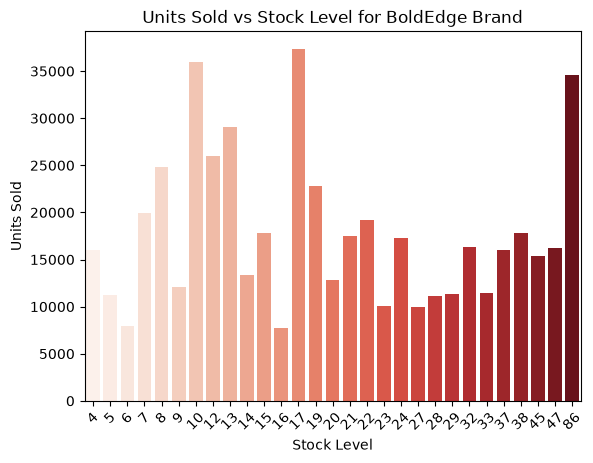

In [144]:
sns.barplot(data=inventory_df, x='stock_level', y='units_sold', color='red', palette='Reds')
plt.title('Units Sold vs Stock Level for BoldEdge Brand')
plt.xlabel('Stock Level')
plt.ylabel('Units Sold')

xticks = plt.xticks(rotation=45)
plt.show()